In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

## ODE models

In [2]:
from scipy.integrate import solve_ivp

## Example 1: Leaky neural activity model

In [3]:
def leaky_activity(t, x, tau, I):
    dxdt = (-x + I) / tau
    return dxdt


tau = 10.0
I = 1.0
x0 = [0.0]

t_eval = np.linspace(0, 100, 500)

sol = solve_ivp(
    leaky_activity,
    t_span=[0, 100],
    y0=x0,
    t_eval=t_eval,
    args=(tau, I)
)

In [4]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.004e-01 ...  9.980e+01  1.000e+02]
        y: [[ 0.000e+00  1.984e-02 ...  9.999e-01  9.999e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 80
     njev: 0
      nlu: 0

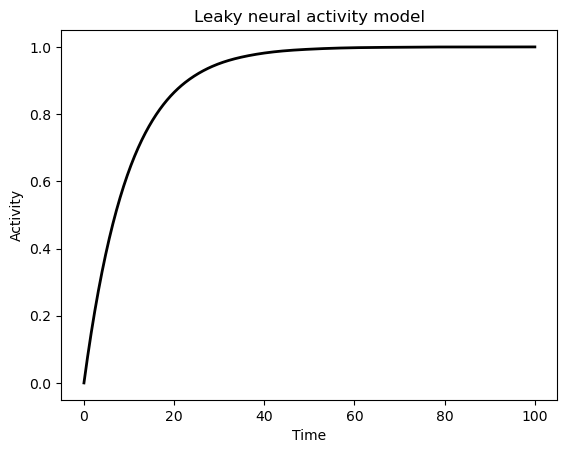

In [5]:
plt.plot(sol.t, sol.y[0], 'k-', lw=2)
plt.xlabel("Time")
plt.ylabel("Activity")
plt.title("Leaky neural activity model")
plt.show()

## change the time constant $\tau$

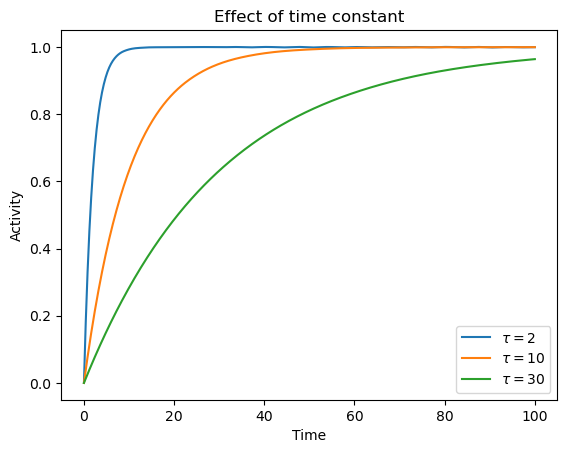

In [6]:
taus = [2, 10, 30]
I = 1.0
x0 = [0.0]

t_eval = np.linspace(0, 100, 500)

for tau in taus:
    sol = solve_ivp(
        leaky_activity,
        [0, 100],
        x0,
        t_eval=t_eval,
        args=(tau, I)
    )
    plt.plot(sol.t, sol.y[0], label=rf"$\tau = {tau}$")

plt.xlabel("Time")
plt.ylabel("Activity")
plt.title("Effect of time constant")
plt.legend()

### Leaky Integrate and Fire model

In [7]:
def lif_subthreshold(t, V, tau_m, V_rest, R, I):
    dVdt = (-(V[0] - V_rest) + R * I) / tau_m
    return [dVdt]


tau_m = 20.0      # ms
V_rest = -65.0    # mV
R = 10.0
I = 2.0

V0 = [-65.0]
t_eval = np.linspace(0, 100, 1000)

sol = solve_ivp(
    lif_subthreshold,
    [0, 100],
    V0,
    t_eval=t_eval,
    args=(tau_m, V_rest, R, I)
)

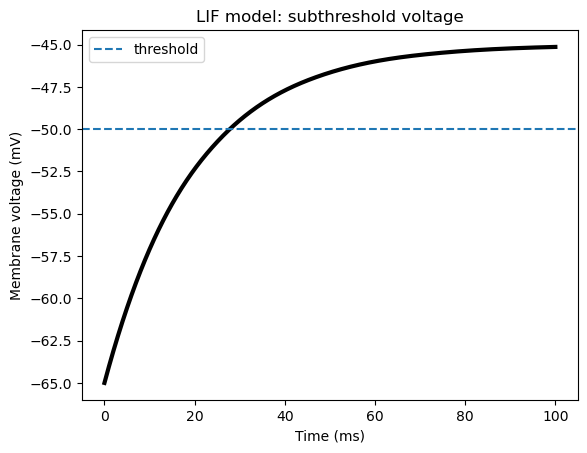

In [17]:
plt.plot(sol.t, sol.y[0], 'k-', lw=3)
plt.axhline(-50, linestyle="--", label="threshold")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane voltage (mV)")
plt.title("LIF model: subthreshold voltage")
plt.legend()

### Event based voltage reset

In [18]:
def lif_rhs(t, V, tau_m, V_rest, R, I):
    dVdt = (-(V[0] - V_rest) + R * I) / tau_m
    return [dVdt]


def threshold_event(t, V, tau_m, V_rest, R, I):
    V_th = -50.0
    return V[0] - V_th


threshold_event.terminal = True
threshold_event.direction = 1


tau_m = 20.0
V_rest = -65.0
V_reset = -65.0
V_th = -50.0
R = 10.0
I = 2.5

t_start = 0.0
t_end = 200.0

current_t = t_start
current_V = [V_reset]

all_t = []
all_V = []
spike_times = []

while current_t < t_end:
    sol = solve_ivp(
        lif_rhs,
        [current_t, t_end],
        current_V,
        max_step=0.1,
        events=threshold_event,
        args=(tau_m, V_rest, R, I)
    )

    all_t.extend(sol.t)
    all_V.extend(sol.y[0])

    if sol.t_events[0].size > 0:
        spike_time = sol.t_events[0][0]
        spike_times.append(spike_time)

        current_t = spike_time
        current_V = [V_reset]

        all_t.append(current_t)
        all_V.append(V_reset)
    else:
        break

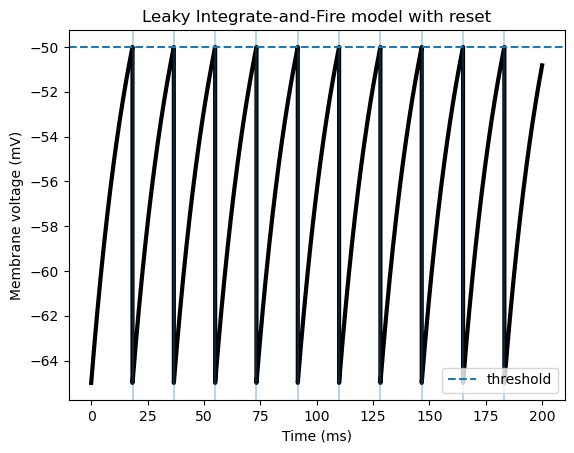

Spike times: [np.float64(18.325814637483123), np.float64(36.65162927496623), np.float64(54.977443912449345), np.float64(73.30325854993247), np.float64(91.62907318741559), np.float64(109.9548878248987), np.float64(128.2807024623818), np.float64(146.60651709986493), np.float64(164.93233173734805), np.float64(183.25814637483117)]


In [20]:
plt.plot(all_t, all_V, 'k-', lw=3)
plt.axhline(V_th, linestyle="--", label="threshold")

for spk in spike_times:
    plt.axvline(spk, alpha=0.3)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane voltage (mV)")
plt.title("Leaky Integrate-and-Fire model with reset")
plt.legend()
plt.show()

print("Spike times:", spike_times)

### Ex 4: E-I rate model

In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def RELU(x):
    return np.tanh(x)


def ei_rate_model(t, z, tau_E, tau_I, w_EE, w_EI, w_IE, w_II, P, Q):
    E, I = z

    dE = (-E + RELU(w_EE * E - w_EI * I + P)) / tau_E
    dI = (-I + RELU(w_IE * E - w_II * I + Q)) / tau_I

    return [dE, dI]


tau_E = 10.0
tau_I = 20.0
w_EE = 10.0
w_EI = 12.0
w_IE = 10.0
w_II = 2.0
P = 0.5
Q = 0.0

z0 = [0.1, 0.1]
t_eval = np.linspace(0, 200, 1000)

sol = solve_ivp(
    ei_rate_model,
    [0, 200],
    z0,
    t_eval=t_eval,
    args=(tau_E, tau_I, w_EE, w_EI, w_IE, w_II, P, Q)
)

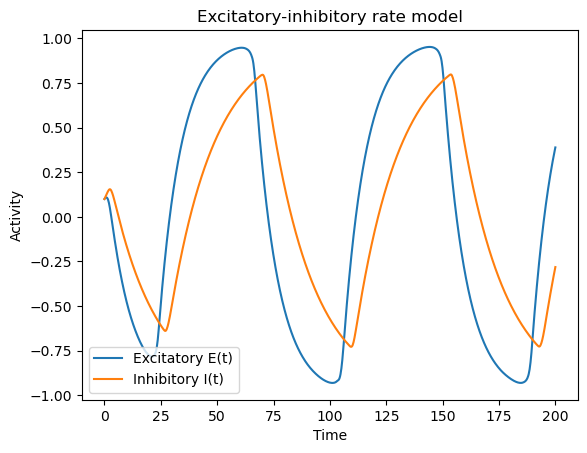

In [14]:

plt.plot(sol.t, sol.y[0], label="Excitatory E(t)")
plt.plot(sol.t, sol.y[1], label="Inhibitory I(t)")
plt.xlabel("Time")
plt.ylabel("Activity")
plt.title("Excitatory-inhibitory rate model")
plt.legend()

## Signal processing with `scipy.signal`

In [18]:
from scipy import signal

### Ex 1

Text(0.5, 1.0, 'Synthetic LFP-like signal')

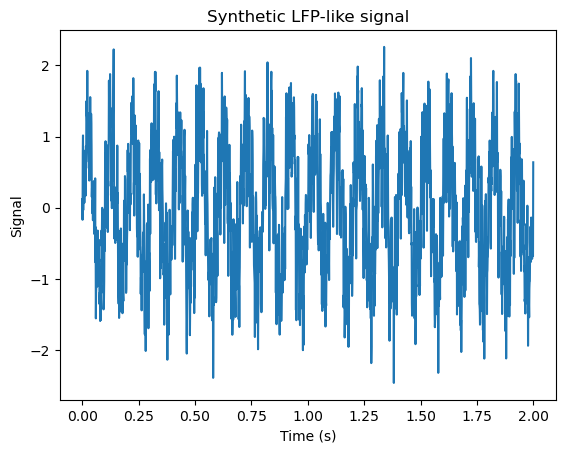

In [15]:
rng = np.random.default_rng(42)

fs = 1000
duration = 2.0

t = np.linspace(0, duration, int(fs * duration), endpoint=False)

x = (
    np.sin(2 * np.pi * 10 * t)
    + 0.5 * np.sin(2 * np.pi * 60 * t)
    + rng.normal(0, 0.4, size=len(t))
)

plt.plot(t, x)
plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Synthetic LFP-like signal")

### Extract the $\alpha$ band: 8-12 Hz

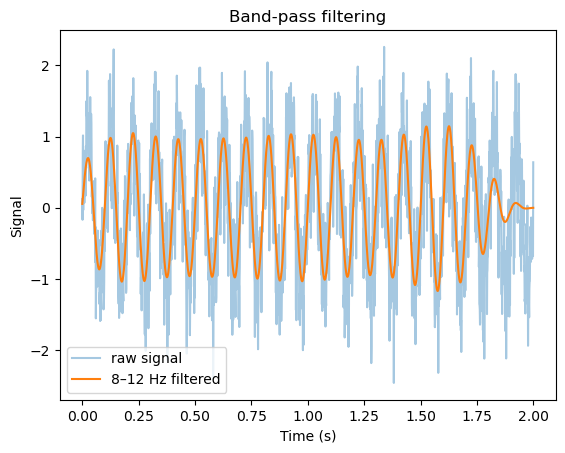

In [19]:
low = 8
high = 12

b, a = signal.butter(
    N=4,
    Wn=[low, high],
    btype="bandpass",
    fs=fs
)

x_alpha = signal.filtfilt(b, a, x)

plt.plot(t, x, alpha=0.4, label="raw signal")
plt.plot(t, x_alpha, label="8–12 Hz filtered")
plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Band-pass filtering")
plt.legend()
plt.show()

### Extract the $\gamma$ band: 30-80 Hz

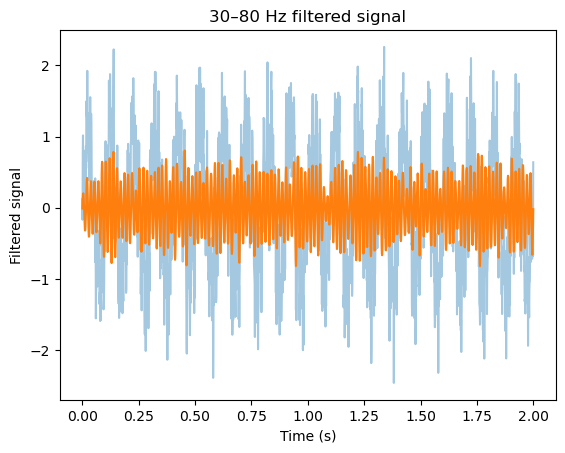

In [20]:
low = 30
high = 80

b, a = signal.butter(
    N=4,
    Wn=[low, high],
    btype="bandpass",
    fs=fs
)

x_gamma = signal.filtfilt(b, a, x)

plt.plot(t, x, alpha=0.4, label="raw signal")
plt.plot(t, x_gamma, label="30-80 Hz filtered")
plt.xlabel("Time (s)")
plt.ylabel("Filtered signal")
plt.title("30–80 Hz filtered signal")
plt.show()

### peak detection

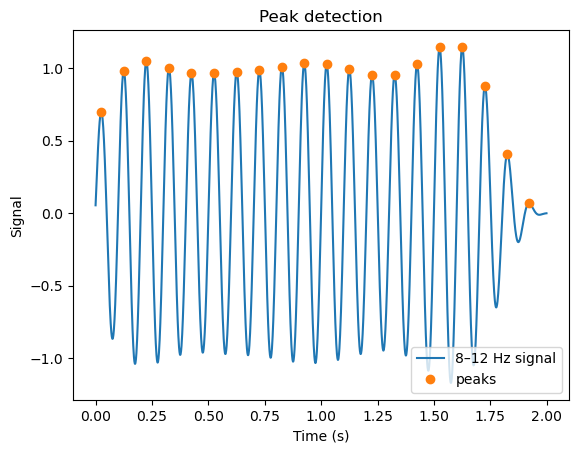

Number of peaks: 20


In [21]:
peaks, properties = signal.find_peaks(
    x_alpha,
    height=0,
    distance=fs // 20
)

plt.plot(t, x_alpha, label="8–12 Hz signal")
plt.plot(t[peaks], x_alpha[peaks], "o", label="peaks")
plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Peak detection")
plt.legend()
plt.show()

print("Number of peaks:", len(peaks))

## Statistics using `scipy.stats`

In [31]:
from scipy import stats

### Ex 1: simulate baseline and stimulus firing rate

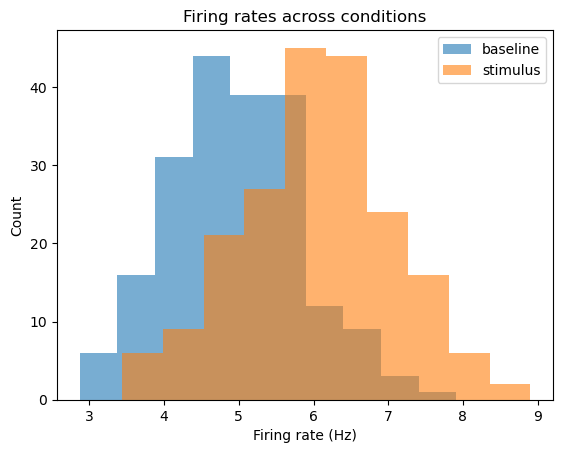

In [36]:
rng = np.random.default_rng(42)

baseline_rates = rng.normal(loc=5.0, scale=1.0, size=200)
stimulus_rates = rng.normal(loc=6.0, scale=1.0, size=200)

plt.hist(baseline_rates, alpha=0.6, label="baseline")
plt.hist(stimulus_rates, alpha=0.6, label="stimulus")
plt.xlabel("Firing rate (Hz)")
plt.ylabel("Count")
plt.title("Firing rates across conditions")
plt.legend()
plt.show()

In [37]:
print("Baseline mean:", baseline_rates.mean())
print("Stimulus mean:", stimulus_rates.mean())

print("Baseline std:", baseline_rates.std(ddof=1))
print("Stimulus std:", stimulus_rates.std(ddof=1))

Baseline mean: 4.9695492753476
Stimulus mean: 6.020077614632491
Baseline std: 0.8819329384620186
Stimulus std: 1.0195048730914034


## independent t-test: use this when two groups are independent

In [38]:
result = stats.ttest_ind(baseline_rates, stimulus_rates)

print("t statistic:", result.statistic)
print("p-value:", result.pvalue)

t statistic: -11.021022700054376
p-value: 7.8553402505156905e-25


### paired t-test

In [39]:
before = rng.normal(loc=5.0, scale=1.0, size=30)
after = before + rng.normal(loc=0.7, scale=0.5, size=30)

result = stats.ttest_rel(before, after)

print("paired t statistic:", result.statistic)
print("p-value:", result.pvalue)

paired t statistic: -8.920965267216332
p-value: 8.235386859047548e-10


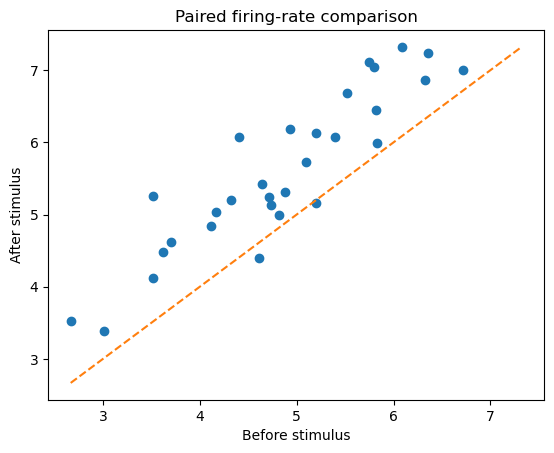

In [40]:
plt.plot(before, after, "o")

low = min(before.min(), after.min())
high = max(before.max(), after.max())

plt.plot([low, high], [low, high], "--")
plt.xlabel("Before stimulus")
plt.ylabel("After stimulus")
plt.title("Paired firing-rate comparison")
plt.show()

### Ex 2. Correlation 

Pearson correlation: -0.7886871847475962
p-value: 1.037685164608746e-11


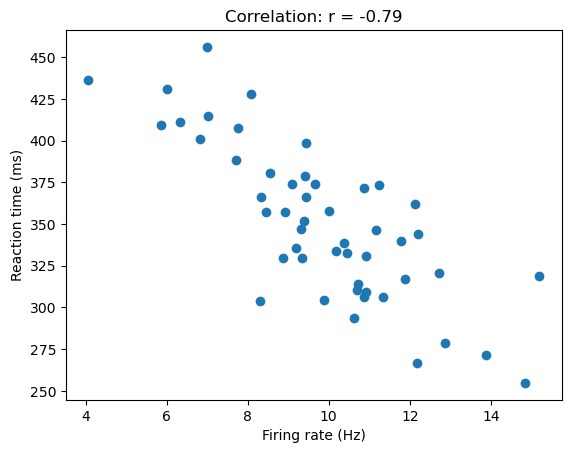

In [41]:
firing_rate = rng.normal(10, 2, size=50)

reaction_time = 500 - 15 * firing_rate + rng.normal(0, 30, size=50)

r, p = stats.pearsonr(firing_rate, reaction_time)

print("Pearson correlation:", r)
print("p-value:", p)

plt.scatter(firing_rate, reaction_time)
plt.xlabel("Firing rate (Hz)")
plt.ylabel("Reaction time (ms)")
plt.title(f"Correlation: r = {r:.2f}")
plt.show()